# Synthetic Data

In [1]:
import os 
import numpy as np
from package import *
save_path = os.getcwd() + '\\' + 'image' + '\\' + 'simulation'+ '\\'

### An example to generate comparison graph 

$n$ is the number of items. <br>
$N$ is the number of comparison/hyperedge. (we allow the multi-edge.) <br>
$v$ is the covariates' coeffecient.<br>
$[m_{lower}, m_{upper})$ is the interval of all possible edge size.

In [ ]:
n = 400
N = lambda n: int(n*(n-1)/2)
v = [1,-0.5,0]
d = len(v)
m_lower = 2
m_upper = 3

complete get edges: Num_Edges=79800, Num_Nodes = 400,m_lower = 2,m_upper = 2


H.T, H.X are two lists containing corresponding item index and covariates.

In [ ]:
H = generator.MultipleComparison(n,N,v,m_lower=m_lower,m_upper=m_upper)
print(f'Number of items:{H.n}')
print(f'Number of comparisons:{H.N}')
#print(f'Comparisons:{H.T}')
#print(f'Covariates:{H.X}')


Number of items:400
Number of comparisons:79800


##### Estimation

Set ''detail = True'' to see the details of alternating method. <br>
Using  ''type='pair' '' can significantly improve the velocity of pairwise case.

In [4]:
detail = True
u_estimation, v_estimation = algorithm.AM(H.T,H.X,n,detail=detail,type = 'pair')

-----1-----
log-likelihood: -0.6931471805588296
v iterative times: 7 and v = [ 0.98395494 -0.4939881   0.01221319]
u iterative times: 21
-----2-----
log-likelihood: -0.5034554039376773
v iterative times: 5 and v = [ 1.02172521 -0.51399931  0.01173552]
u iterative times: 10
u iterative times: 2


In [ ]:
detail = True
u_estimation, v_estimation = algorithm.AM(H.T,H.X,n,d,detail=detail,type = 'multi')

-----1-----
log-likelihood: -0.6931471805588296
v iterative times: 6 and v = [ 0.96352078 -0.48720692  0.00762969]
u iterative times: 21
-----2-----
log-likelihood: -0.5066295092267757
v iterative times: 4 and v = [ 0.99896165 -0.5052607   0.0099707 ]
u iterative times: 10


##### Error bound

In [ ]:
u_true, v_true = H.u,H.v
u_infty = max(abs(u_estimation-u_true))
v_infty = max(abs(v_estimation-v_true))

print(f'u_infty:{u_infty}')
print(f'v_infty:{v_infty}')

u_infty:0.4647840363322926
v_infty:0.01002895996317777


##### Convergence rate

In [4]:
U = [np.zeros(n)]
V = [np.zeros(d)]
UU,VV = [],[]
for i in range(3):
    U = MM_pair(H.T,H.X,V[-1],n,utr=U[-1])
    V = Newton_pair(H.T,H.X,U[-1],d,vtr=V[-1],E=1e-12)
    U_error = [np.linalg.norm(u-U[-1]) for u in U[:-1]]
    U_error_ratio = [U_error[i+1]/U_error[i] for i in range(len(U_error)-1)]
    V_error = [np.linalg.norm(v-V[-1]) for v in V[:-1]]
    V_error_ratio = [V_error[i+1]/V_error[i] for i in range(len(V_error)-1)]
    #UU.append(U_error_ratio)
    #VV.append(V_error_ratio)
    UU.append(U_error)
    VV.append(V_error)


C:\Users\13299\AppData\Local\Temp\ipykernel_15012\782564531.py:32: RuntimeWarning: invalid value encountered in log
  ax.plot(range(len(V)),np.log(-np.log(V)),T[i],label = fr"Alterating times: $\tau_1 = {i}$",)


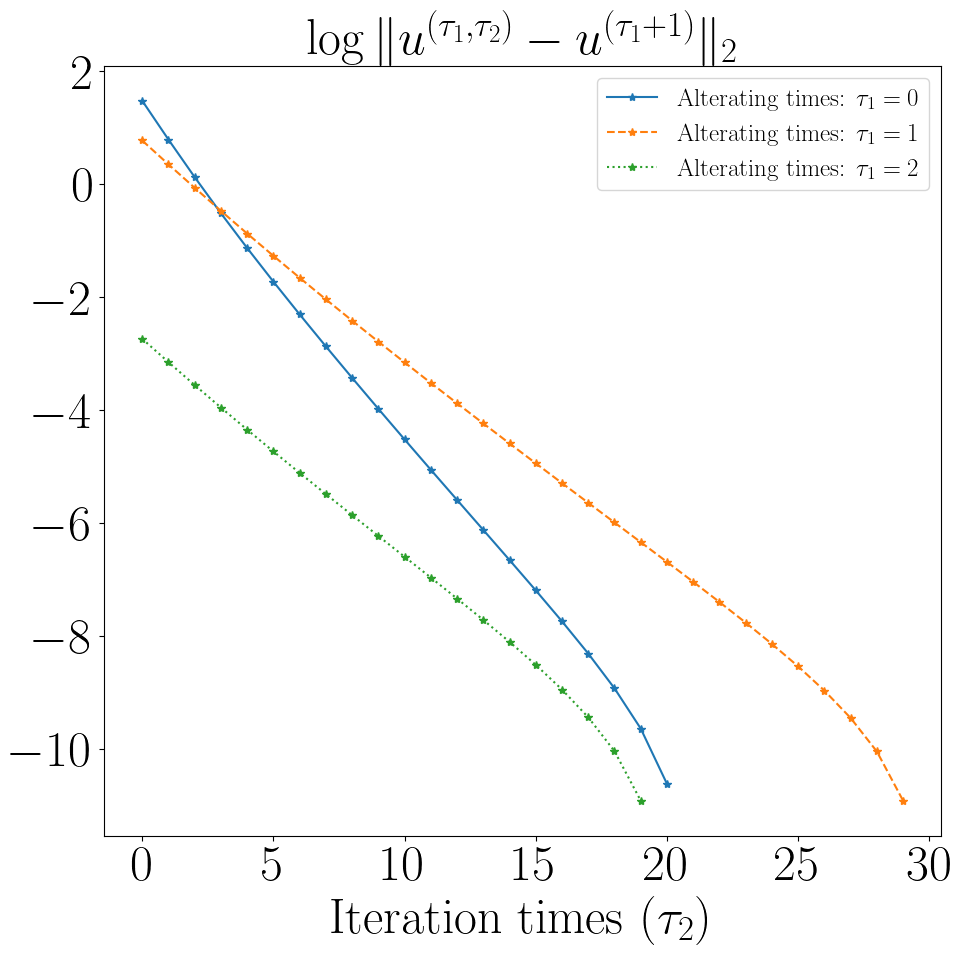

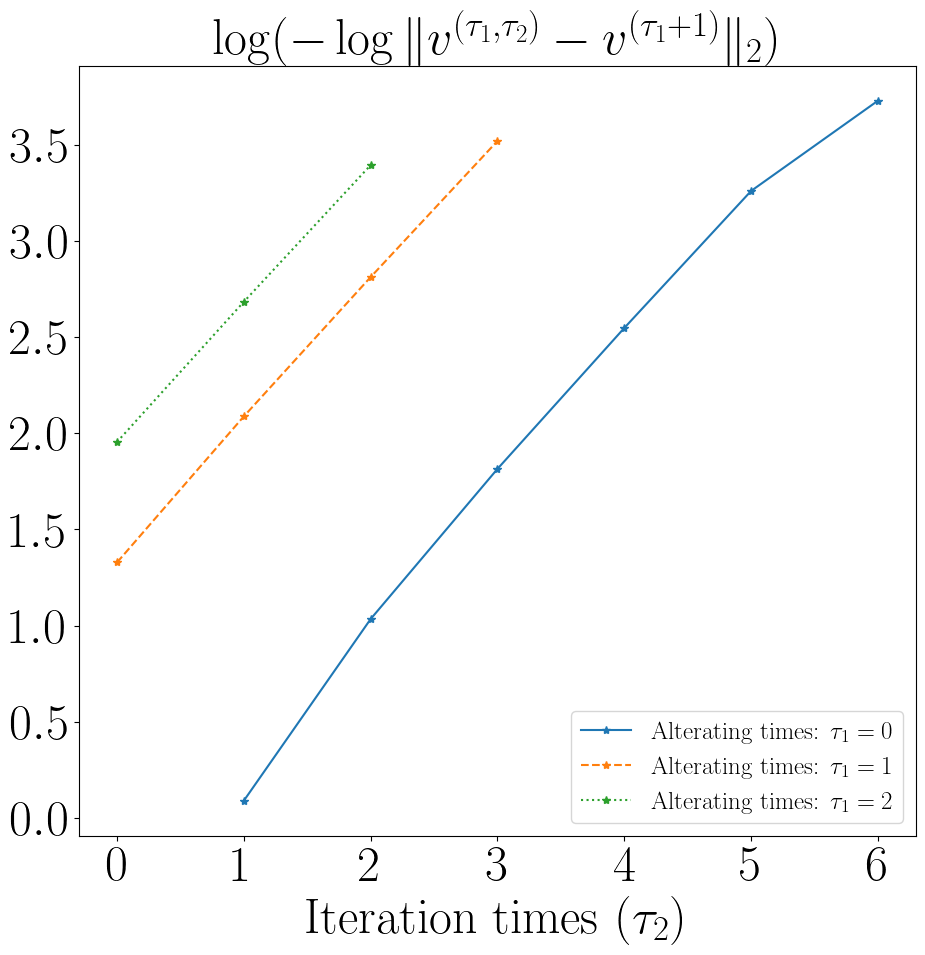

In [21]:
import matplotlib.pyplot as plt

T = ['-*','--*',':*',':']
rc('text', usetex=True)
rc('font', family='serif')
sz = 36

title = ""
#Tu_ = r'$\frac{\|u^{(\tau_1,\tau_2+1)}-u^{(\tau_1+1)}\|_2}{\|u^{(\tau_1,\tau_2)}-u^{(\tau_1+1)}\|_2}$'
Tu_ = r'$\log\|u^{(\tau_1,\tau_2)}-u^{(\tau_1+1)}\|_2$'
#Tv_ = r'$\frac{\|v^{(\tau_1,\tau_2+1)}-v^{(\tau_1+1)}\|_2}{\|v^{(\tau_1,\tau_2)}-v^{(\tau_1+1)}\|_2}$'
Tv_ = r'$\log(-\log\|v^{(\tau_1,\tau_2)}-v^{(\tau_1+1)}\|_2)$'
ylabel = 'Error ratio'
xlabel = r'Iteration times ($\tau_2$)'

fig, ax = plt.subplots(figsize=(10.8, 10))
plt.xticks(size=sz)
plt.yticks(size=sz)
plt.title(title+Tu_,size =sz)
for i,U in enumerate(UU):
    ax.plot(range(len(U)),np.log(U),T[i],label = fr"Alterating times: $\tau_1 = {i}$",)
    #ax.plot(np.log(U[:-1]),np.log(U[1:])-np.log(U[:-1]),T[i],label = fr"Alterating times: $\tau_1 = {i}$",)
    ax.set_xlabel(xlabel,size = sz)
plt.legend(fontsize=sz/2)
plt.savefig(save_path+'convergence_rate_u.pdf')

fig, ax = plt.subplots(figsize=(10.8, 10))
plt.title(title+Tv_,size =sz)
plt.xticks(size=sz)
plt.yticks(size=sz)
for i,V in enumerate(VV):
    ax.plot(range(len(V)),np.log(-np.log(V)),T[i],label = fr"Alterating times: $\tau_1 = {i}$",)
    #ax.plot(np.log(V[:-1]),np.log(V[1:])-np.log(V[:-1]),T[i],label = fr"Alterating times: $\tau_1 = {i}$",)
    ax.set_xlabel(xlabel,size = sz)
plt.legend(fontsize=sz/2)
plt.savefig(save_path+'convergence_rate_v.pdf')


plt.show()

##### Does covariate fully capture the score?

In [44]:
n = 100
N = lambda n: int(n*(n-1)/2)
u_generator = lambda n: np.array([i/10 for i in range(n)])-np.mean(np.array([i/10 for i in range(n)]))
v = [1,-0.5,0]
d = len(v)
H = generator.MultipleComparison(n,N,v,u_generator=u_generator)

complete get edges: Num_Edges=4950, Num_Nodes = 100,m_lower = 2,m_upper = 2


In [45]:
u,v =algorithm.AM(H.T,H.X,n,d,type='pair',v = H.v,P=False)


In [ ]:
index = u.argsort()
index

array([ 4,  0,  7, 10,  1,  6,  8,  3,  2, 12, 11,  5, 13, 17, 16, 14, 19,
        9, 15, 21, 18, 22, 20, 25, 24, 29, 30, 36, 35, 26, 28, 23, 37, 31,
       27, 38, 32, 40, 41, 34, 33, 43, 45, 48, 44, 42, 46, 39, 52, 49, 47,
       51, 55, 50, 56, 59, 54, 53, 58, 62, 61, 57, 63, 64, 60, 69, 65, 66,
       68, 70, 71, 72, 67, 76, 74, 73, 77, 78, 75, 87, 83, 81, 79, 80, 86,
       84, 82, 91, 90, 92, 88, 94, 85, 89, 95, 97, 93, 98, 96, 99],
      dtype=int64)

: 